# EDA: Machine Learning Engineer Maoshlari Dataseti

Bu notebookda `ML_Engineeer.csv` dataseti ustida **Exploratory Data Analysis (EDA)** o'tkazamiz.

Dataset Machine Learning Engineer lavozimidagi xodimlarning:
* tajriba darajasi (`experience_level`)
* ish turi (`employment_type`)
* maoshi (`salary_in_usd`)
* masofaviy ishlash darajasi (`remote_ratio`)
* kompaniya joylashuvi va o'lchami

kabi ma'lumotlarini o'z ichiga oladi.

---

## 1. Kutubxonalarni import qilish va datasetni yuklash

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('../Data/ML_Engineeer.csv')
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,Machine Learning Engineer,296300,USD,296300,US,0,US,M
1,2024,SE,FT,Machine Learning Engineer,166600,USD,166600,US,0,US,M
2,2024,SE,FT,Machine Learning Engineer,264200,USD,264200,US,0,US,M
3,2024,SE,FT,Machine Learning Engineer,143100,USD,143100,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,50000,EUR,55555,LT,0,LT,M


## 2. Umumiy ma'lumot

Dataset shakli, ustunlar turi va bo'sh (missing) qiymatlarni tekshiramiz.

In [4]:
print('Qatorlar va ustunlar soni:', df.shape)
df.info()

Qatorlar va ustunlar soni: (4144, 11)
<class 'pandas.DataFrame'>
RangeIndex: 4144 entries, 0 to 4143
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           4144 non-null   int64
 1   experience_level    4144 non-null   str  
 2   employment_type     4144 non-null   str  
 3   job_title           4144 non-null   str  
 4   salary              4144 non-null   int64
 5   salary_currency     4144 non-null   str  
 6   salary_in_usd       4144 non-null   int64
 7   employee_residence  4144 non-null   str  
 8   remote_ratio        4144 non-null   int64
 9   company_location    4144 non-null   str  
 10  company_size        4144 non-null   str  
dtypes: int64(4), str(7)
memory usage: 356.3 KB


In [5]:
print("Bo'sh (missing) qiymatlar soni:")
df.isnull().sum()

Bo'sh (missing) qiymatlar soni:


work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [6]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,4144.000000,4.144000e+03,4144.000000,4144.000000
mean,2023.662162,2.034653e+05,197720.979006,19.546332
std,0.574002,1.984839e+05,71334.893748,39.492762
min,2020.000000,1.400000e+04,15966.000000,0.000000
25%,2023.000000,1.450000e+05,144575.000000,0.000000
50%,2024.000000,1.900000e+05,189775.000000,0.000000
75%,2024.000000,2.405000e+05,240240.000000,0.000000
max,2024.000000,8.500000e+06,750000.000000,100.000000


Bo'sh qiymatlar mavjud emas, shuning uchun EDA'ni to'g'ridan-to'g'ri grafiklar bilan davom ettiramiz.

---

## 3. Grafik 1 — Maoshning (salary_in_usd) taqsimoti (Histogram)

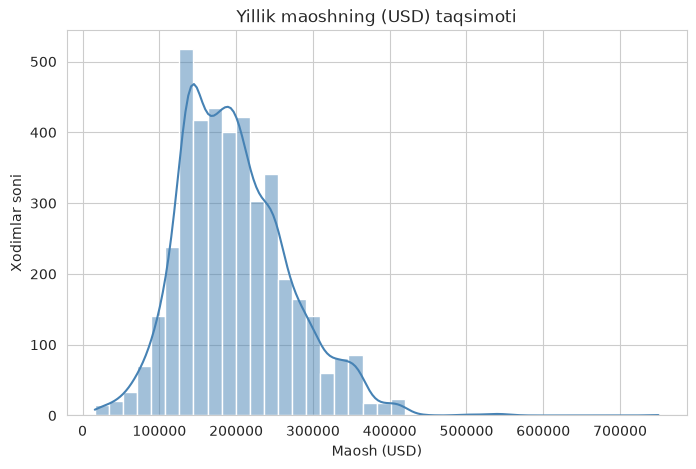

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['salary_in_usd'], bins=40, kde=True, color='steelblue')
plt.title("Yillik maoshning (USD) taqsimoti")
plt.xlabel('Maosh (USD)')
plt.ylabel('Xodimlar soni')
plt.show()

**Izoh:** Maoshlarning ko'pchiligi 150,000–250,000 USD oralig'ida to'plangan, taqsimot o'ngga cho'zilgan (right-skewed).

---

## 4. Grafik 2 — Tajriba darajasi bo'yicha xodimlar soni (Bar chart)

/tmp/ipykernel_19699/2899418212.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='experience_level', order=order, palette='viridis')


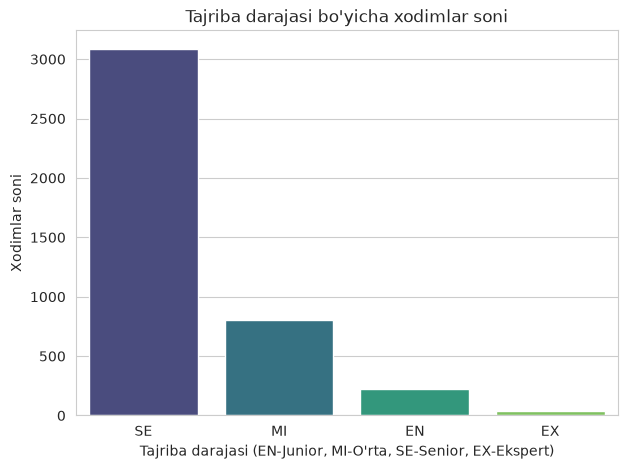

In [8]:
order = df['experience_level'].value_counts().index

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='experience_level', order=order, palette='viridis')
plt.title("Tajriba darajasi bo'yicha xodimlar soni")
plt.xlabel("Tajriba darajasi (EN-Junior, MI-O'rta, SE-Senior, EX-Ekspert)")
plt.ylabel('Xodimlar soni')
plt.show()

**Izoh:** Datasetdagi xodimlarning aksariyati **Senior (SE)** darajasiga tegishli.

---

## 5. Grafik 3 — Tajriba darajasi bo'yicha maosh (Boxplot)

/tmp/ipykernel_19699/2098324385.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level', y='salary_in_usd', order=['EN', 'MI', 'SE', 'EX'], palette='Set2')


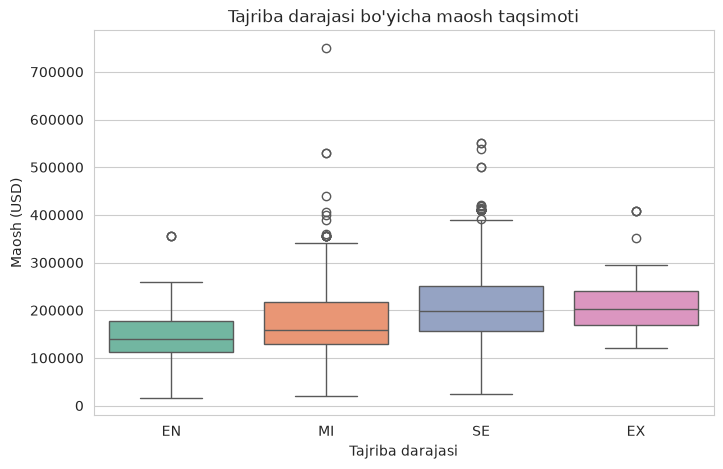

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='experience_level', y='salary_in_usd', order=['EN', 'MI', 'SE', 'EX'], palette='Set2')
plt.title("Tajriba darajasi bo'yicha maosh taqsimoti")
plt.xlabel('Tajriba darajasi')
plt.ylabel('Maosh (USD)')
plt.show()

**Izoh:** Tajriba darajasi oshgan sari o'rtacha maosh ham izchil ravishda oshib boradi — bu kutilgan natija.

---

## 6. Grafik 4 — Kompaniya o'lchami bo'yicha maosh (Violin plot)

/tmp/ipykernel_19699/441622731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='company_size', y='salary_in_usd', order=['S', 'M', 'L'], palette='muted')


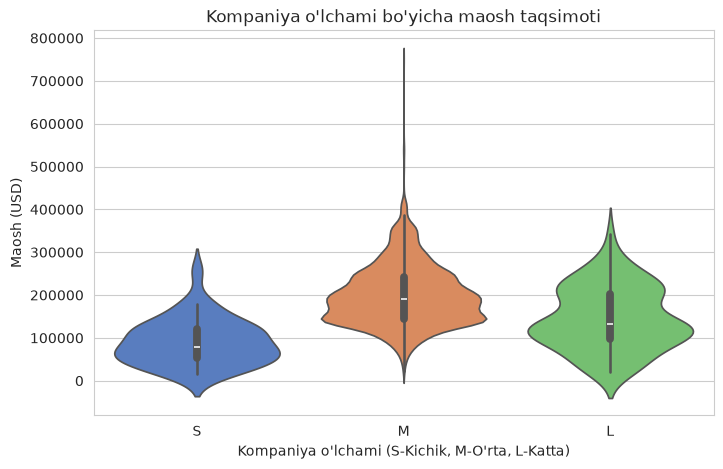

In [10]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='company_size', y='salary_in_usd', order=['S', 'M', 'L'], palette='muted')
plt.title("Kompaniya o'lchami bo'yicha maosh taqsimoti")
plt.xlabel("Kompaniya o'lchami (S-Kichik, M-O'rta, L-Katta)")
plt.ylabel('Maosh (USD)')
plt.show()

**Izoh:** O'rta (M) o'lchamdagi kompaniyalar dataset ichida ustunlik qiladi va maosh tarqalishi ham kengroq.

---

## 7. Grafik 5 — Yillar bo'yicha o'rtacha maosh dinamikasi (Line chart)

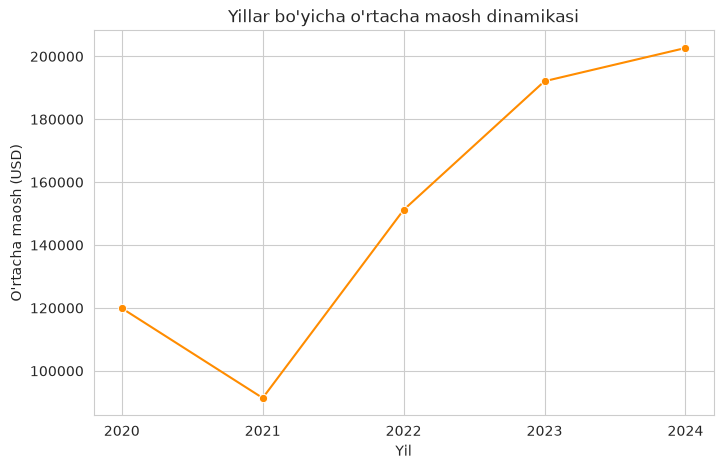

In [11]:
yearly_avg = df.groupby('work_year')['salary_in_usd'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=yearly_avg, x='work_year', y='salary_in_usd', marker='o', color='darkorange')
plt.title("Yillar bo'yicha o'rtacha maosh dinamikasi")
plt.xlabel('Yil')
plt.ylabel("O'rtacha maosh (USD)")
plt.xticks(yearly_avg['work_year'])
plt.show()

**Izoh:** Yillar davomida o'rtacha maosh o'sish tendensiyasini ko'rsatadi, so'nggi yillarda ML Engineer kasbi tobora qadrlanmoqda.

---

## 8. Grafik 6 — Masofaviy ishlash darajasi ulushi (Pie chart)

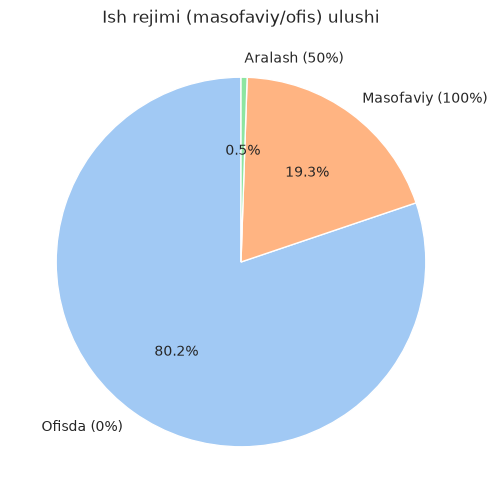

In [12]:
remote_counts = df['remote_ratio'].value_counts()
labels = {0: 'Ofisda (0%)', 50: 'Aralash (50%)', 100: 'Masofaviy (100%)'}

plt.figure(figsize=(6, 6))
plt.pie(
    remote_counts.values,
    labels=[labels[i] for i in remote_counts.index],
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)
plt.title('Ish rejimi (masofaviy/ofis) ulushi')
plt.show()

**Izoh:** Xodimlarning aksariyati (~80%) to'liq ofisda ishlaydi, faqat kichik qismi to'liq masofaviy ishlaydi.

---

## 9. Grafik 7 — Eng ko'p uchraydigan 10 ta kompaniya joylashuvi (Horizontal bar)

/tmp/ipykernel_19699/2234489143.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='crest')


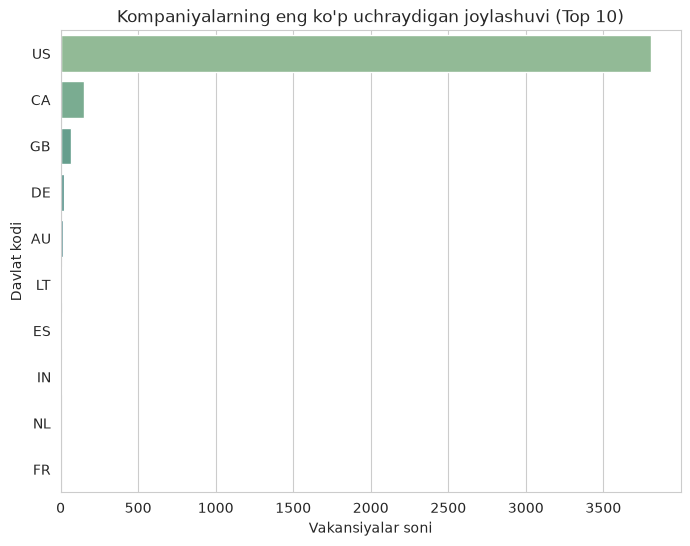

In [13]:
top_locations = df['company_location'].value_counts().head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='crest')
plt.title("Kompaniyalarning eng ko'p uchraydigan joylashuvi (Top 10)")
plt.xlabel('Vakansiyalar soni')
plt.ylabel('Davlat kodi')
plt.show()

**Izoh:** Vakansiyalarning katta qismi **AQSH (US)**da joylashgan kompaniyalarga tegishli.

---

## 10. Grafik 8 — Maosh va masofaviy ishlash o'rtasidagi bog'liqlik (Scatter plot)

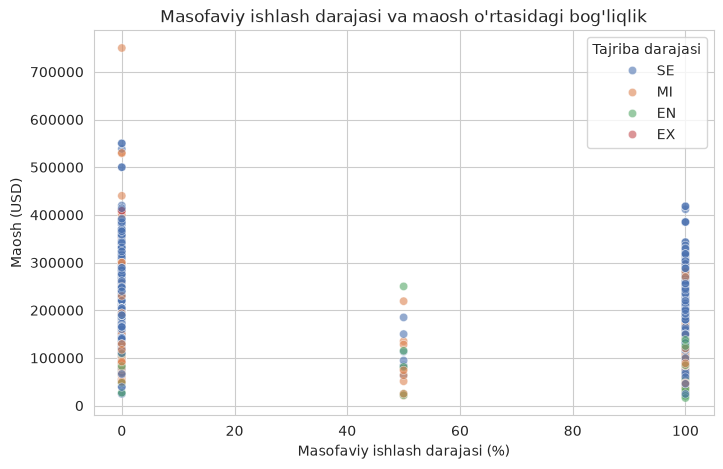

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='remote_ratio',
    y='salary_in_usd',
    hue='experience_level',
    palette='deep',
    alpha=0.6
)
plt.title("Masofaviy ishlash darajasi va maosh o'rtasidagi bog'liqlik")
plt.xlabel('Masofaviy ishlash darajasi (%)')
plt.ylabel('Maosh (USD)')
plt.legend(title='Tajriba darajasi')
plt.show()

**Izoh:** Maosh darajasi asosan tajriba darajasiga bog'liq, masofaviy ishlash foizi bilan aniq chiziqli bog'liqlik ko'rinmaydi.

---

## 11. Umumiy xulosa

* Dataset asosan **Senior** darajadagi va **AQSH**da joylashgan **o'rta o'lchamdagi** kompaniyalarni o'z ichiga oladi.
* Maosh eng ko'p **tajriba darajasi**ga bog'liq, keyin esa kompaniya o'lchamiga.
* Yillar o'tishi bilan o'rtacha maosh o'sish tendensiyasini ko'rsatmoqda.
* Xodimlarning aksariyati to'liq ofisda ishlaydi, masofaviy ishlash ulushi nisbatan kam.